# E01 Matrix Sensing Dimension Benchmark

### Problem

This notebook is a dimension-scaling benchmark for direct Matrix Sensing. For each dimension $d$, target rank $r$, and number of measurements $m$, the unknown matrix $X^\star\in\mathbb{R}^{d\times d}$ is observed through random linear measurements

$$y_i=\langle A_i,X^\star\rangle+\xi_i,\qquad i=1,\ldots,m,$$

where $\langle A,X\rangle=\operatorname{tr}(A^\top X)$. Each optimizer directly updates a dense matrix $X\in\mathbb{R}^{d\times d}$ by minimizing

$$f(X)=\frac{1}{2m}\sum_{i=1}^{m}(\langle A_i,X\rangle-y_i)^2.$$

The target distribution is generated by random singular vectors and a controlled spectrum. The implementation samples independent Gaussian matrices $G_U,G_V\in\mathbb{R}^{d\times d}$, takes QR factors $U,V$, and sets

$$X^\star=U\operatorname{diag}(s_1,\ldots,s_d)V^\top.$$

In this benchmark, `spectrum="hard-cutoff"`, `kappa=1`, and `rank=5`, so $s_j=\mathbf{1}\{j\le r\}$ with $r=5$. The measurement distribution is Gaussian,

$$A_i[j,k]\overset{\mathrm{i.i.d.}}{\sim}\mathcal{N}(0,1),\qquad m=2dr,$$

and `noise=0`, so $\xi_i=0$. The optimization variable starts from

$$X_0=s_{\mathrm{init}}G_0,\qquad G_0[j,k]\overset{\mathrm{i.i.d.}}{\sim}\mathcal{N}(0,1),\qquad s_{\mathrm{init}}=10^{-2}.$$

The experiment fixes the target law, measurement law, noise level, rank, initialization scale, and learning rate; it varies only $d$, optimizer, and seed. Its purpose is to answer whether optimizer behavior changes with ambient matrix dimension when the statistical problem is otherwise held fixed.

When reading the results, focus first on final/minimum loss versus $d$, then on the same-$d$ log-loss curves to compare convergence shape, and finally on actual steps and wall-clock time. The runtime matters because one step evaluates $m$ dense matrix inner products, so the dominant work scales as $\Theta(md^2)=\Theta(2rd^3)$. With $5$ optimizers, $3$ dimensions, $20$ seeds, and up to $2000$ steps, this notebook can execute up to $600000$ optimization steps.

In [1]:
import os
import pathlib
import sys
import time
for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import joblib
import IPython.display
import matplotlib.pyplot as plt
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import plotting
import problems.MatrixConstruction
import problems.MatrixSensing
import util

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")
print(f"joblib  = {joblib.__version__}")

project = /Users/tianyangliu/Desktop/muonexperiment
torch   = 2.11.0
joblib  = 1.4.2


### Parameters And Runs

Before execution, `runs` is one row per independent run. The execution cell replaces it with a long per-step table: one row per `(run_id, step)`.

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon", "Muon-Exact", "Shampoo", "Adam", "SGD"]
DIMS = [50, 60, 70]
SEEDS = list(range(20))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 2000

BASE_SPEC = dict(
    rank=5,
    lr=0.01,
    noise=0.0,
    dist="normal",
    spectrum="hard-cutoff",
    kappa=1.0,
    init_scale=0.01,
    iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
    early_stop=True,
    early_stop_min_steps=20,
    early_stop_patience=20,
    early_stop_min_delta=1e-3,
    device_type=DEVICE.type,
    dtype_name=DTYPE_NAME,
)
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([
    {**BASE_SPEC, "algo": algo, "d": d, "seed": seed}
    for algo in ALGOS
    for d in DIMS
    for seed in SEEDS
])
runs["problem"] = "MatrixSensing"
runs["r"] = runs["rank"]
runs["m_meas"] = 2 * runs["d"] * runs["rank"]
runs.insert(0, "run_id", range(len(runs)))
runs = runs[[
    "run_id", "problem", "algo", "d", "rank", "r", "m_meas", "seed", "lr", "iters",
    "early_stop", "early_stop_min_steps", "early_stop_patience", "early_stop_min_delta",
    "noise", "dist", "spectrum", "kappa", "init_scale", "device_type", "dtype_name",
]]

print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, smoke_test_max_steps={SMOKE_TEST_MAX_STEPS}")
print(f"runs={len(runs)}, max_iters={BASE_SPEC['iters']}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
print(
    "early_stop=patience on absolute loss improvement "
    f"(min_steps={BASE_SPEC['early_stop_min_steps']}, "
    f"patience={BASE_SPEC['early_stop_patience']}, "
    f"min_delta={BASE_SPEC['early_stop_min_delta']})"
)
IPython.display.display(runs)

device=cpu, workers=8, backend=loky
smoke_test=False, smoke_test_max_steps=10
runs=300, max_iters=2000, max_total_steps=600000
early_stop=patience on absolute loss improvement (min_steps=20, patience=20, min_delta=0.001)


,run_id,problem,algo,d,rank,r,m_meas,seed,lr,iters,...,early_stop_min_steps,early_stop_patience,early_stop_min_delta,noise,dist,spectrum,kappa,init_scale,device_type,dtype_name
0,0,MatrixSensing,Muon,50,5,5,500,0,0.01,2000,...,20,20,0.001,0.0,normal,hard-cutoff,1.0,0.01,cpu,float64
1,1,MatrixSensing,Muon,50,5,5,500,1,0.01,2000,...,20,20,0.001,0.0,normal,hard-cutoff,1.0,0.01,cpu,float64
2,2,MatrixSensing,Muon,50,5,5,500,2,0.01,2000,...,20,20,0.001,0.0,normal,hard-cutoff,1.0,0.01,cpu,float64
3,3,MatrixSensing,Muon,50,5,5,500,3,0.01,2000,...,20,20,0.001,0.0,normal,hard-cutoff,1.0,0.01,cpu,float64
4,4,MatrixSensing,Muon,50,5,5,500,4,0.01,2000,...,20,20,0.001,0.0,normal,hard-cutoff,1.0,0.01,cpu,float64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,295,MatrixSensing,SGD,70,5,5,700,15,0.01,2000,...,20,20,0.001,0.0,normal,hard-cutoff,1.0,0.01,cpu,float64
296,296,MatrixSensing,SGD,70,5,5,700,16,0.01,2000,...,20,20,0.001,0.0,normal,hard-cutoff,1.0,0.01,cpu,float64
297,297,MatrixSensing,SGD,70,5,5,700,17,0.01,2000,...,20,20,0.001,0.0,normal,hard-cutoff,1.0,0.01,cpu,float64
298,298,MatrixSensing,SGD,70,5,5,700,18,0.01,2000,...,20,20,0.001,0.0,normal,hard-cutoff,1.0,0.01,cpu,float64


### Single Run

The function below implements one row of `runs`: it samples the Matrix Sensing instance, samples $X_0$, applies the selected optimizer, and returns one record per optimization step.

In [3]:
def single_run(run):
    run = dict(run)
    d, rank, seed, iters = int(run["d"]), int(run["rank"]), int(run["seed"]), int(run["iters"])
    early_stop = bool(run["early_stop"])
    early_stop_min_steps = int(run["early_stop_min_steps"])
    early_stop_patience = int(run["early_stop_patience"])
    early_stop_min_delta = float(run["early_stop_min_delta"])
    device = torch.device(run["device_type"])
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)

    def initialize_problem(run):
        return problems.MatrixSensing.make_matrix_sensing_problem(
            d,
            rank,
            noise=float(run["noise"]),
            dist=run["dist"],
            spectrum=run["spectrum"],
            kappa=float(run["kappa"]),
            seed=seed,
            device=device,
            dtype=dtype,
        )

    def optimization(problem, run):
        x = torch.nn.Parameter(problems.MatrixConstruction.randn((d, d), seed + 3000, device, dtype) * float(run["init_scale"]))
        state = {
            "problem": problem,
            "x": x,
            "optimizer": make_optimizer(run["algo"], [x], float(run["lr"]), rank),
            "step": 0,
            "best_loss": None,
            "early_stop_wait": 0,
        }

        def step(state):
            state["optimizer"].zero_grad(set_to_none=True)
            loss = state["problem"].loss(state["x"])
            loss.backward()
            state["grad_norm"] = float(state["x"].grad.detach().norm().cpu())
            state["optimizer"].step()
            state["step"] += 1
            state["loss"] = float(loss.detach().cpu())
            return state

        def update_early_stop_state(state):
            if state["best_loss"] is None:
                state["best_loss"] = state["loss"]
                return state
            absolute_improvement = state["best_loss"] - state["loss"]
            if absolute_improvement >= early_stop_min_delta:
                state["best_loss"] = state["loss"]
                state["early_stop_wait"] = 0
            else:
                state["early_stop_wait"] += 1
            return state

        def should_stop(state):
            return (
                early_stop
                and state["step"] >= early_stop_min_steps
                and state["early_stop_wait"] >= early_stop_patience
            )

        def stepwise_data(state, stop_reason=""):
            return {
                **run,
                "step": state["step"],
                "loss": state["loss"],
                "grad_norm": state["grad_norm"],
                "best_loss": state["best_loss"],
                "early_stop_wait": state["early_stop_wait"],
                "elapsed_s": time.time() - t0,
                "stop_reason": stop_reason,
            }

        records = []
        if device.type == "cuda":
            torch.cuda.synchronize(device)
        t0 = time.time()
        for _ in range(iters):
            state = step(state)
            state = update_early_stop_state(state)
            stop_reason = "early_stop_patience" if should_stop(state) else ""
            records.append(stepwise_data(state, stop_reason))
            if stop_reason:
                break
        if records and not records[-1]["stop_reason"]:
            records[-1]["stop_reason"] = "max_iters"
        if device.type == "cuda":
            torch.cuda.synchronize(device)
        return pd.DataFrame(records)

    problem = initialize_problem(run)
    run.update(d=d, rank=rank, r=rank, m_meas=problem.m_meas, seed=seed, iters=iters)
    return optimization(problem, run)

### Runtime Helpers

In [4]:
def dtype_from_name(name):
    dtype = getattr(torch, name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_optimizer(algo, params, lr, rank):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=5)
    if algo in {"Muon-Exact", "MuonExact"}:
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="exact")
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr, beta2=0.9, epsilon=1e-8)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    raise ValueError(f"unknown algo: {algo}")

### Plotting API

In [5]:
for module_name in list(sys.modules):
    if module_name == "plotting" or module_name.startswith("plotting."):
        sys.modules.pop(module_name)

import plotting


def show_figure(fig):
    IPython.display.display(fig)
    plt.close(fig)

## Results

The execute cell materializes the long per-step `runs` table. The saved outputs below are the experimental results to inspect.

In [6]:
runs = util.run_experiments(runs, single_run, num_workers=NUM_WORKERS, backend=JOBLIB_BACKEND, algo_order=ALGOS)
IPython.display.display(runs)

runs (8 joblib):   0%|          | 0/300 [00:00<?, ?run/s]

runs (8 joblib):   0%|          | 1/300 [00:02<12:53,  2.59s/run]

runs (8 joblib):   7%|▋         | 20/300 [00:03<00:40,  6.95run/s]

runs (8 joblib):  12%|█▏        | 36/300 [00:04<00:27,  9.77run/s]

runs (8 joblib):  16%|█▋        | 49/300 [00:06<00:28,  8.86run/s]

...

runs (8 joblib):  72%|███████▏  | 216/300 [00:11<00:02, 28.48run/s]

runs (8 joblib):  82%|████████▏ | 247/300 [00:13<00:02, 23.55run/s]

runs (8 joblib):  92%|█████████▏| 277/300 [00:14<00:00, 25.12run/s]

runs (8 joblib): 100%|██████████| 300/300 [00:15<00:00, 18.77run/s]

,run_id,problem,algo,d,rank,r,m_meas,seed,lr,iters,...,init_scale,device_type,dtype_name,step,loss,grad_norm,best_loss,early_stop_wait,elapsed_s,stop_reason
0,0,MatrixSensing,Muon,50,5,5,500,0,0.01,2000,...,0.01,cpu,float64,1,2.862266,5.906715,2.862266,0,0.055554,
1,0,MatrixSensing,Muon,50,5,5,500,0,0.01,2000,...,0.01,cpu,float64,2,2.579530,5.561344,2.579530,0,0.059779,
2,0,MatrixSensing,Muon,50,5,5,500,0,0.01,2000,...,0.01,cpu,float64,3,2.314240,5.219699,2.314240,0,0.060577,
3,0,MatrixSensing,Muon,50,5,5,500,0,0.01,2000,...,0.01,cpu,float64,4,2.066868,4.882877,2.066868,0,0.061381,
4,0,MatrixSensing,Muon,50,5,5,500,0,0.01,2000,...,0.01,cpu,float64,5,1.837425,4.552101,1.837425,0,0.061977,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24473,299,MatrixSensing,SGD,70,5,5,700,19,0.01,2000,...,0.01,cpu,float64,90,0.000127,0.045787,0.000650,16,0.318716,
24474,299,MatrixSensing,SGD,70,5,5,700,19,0.01,2000,...,0.01,cpu,float64,91,0.000111,0.042539,0.000650,17,0.321463,
24475,299,MatrixSensing,SGD,70,5,5,700,19,0.01,2000,...,0.01,cpu,float64,92,0.000098,0.039646,0.000650,18,0.324161,
24476,299,MatrixSensing,SGD,70,5,5,700,19,0.01,2000,...,0.01,cpu,float64,93,0.000087,0.037392,0.000650,19,0.327260,


### Result Tables

In [7]:
ordered_runs = runs.sort_values(["run_id", "step"])

run_summary = ordered_runs.groupby("run_id", as_index=False).first()
run_summary = run_summary.drop(
    columns=["step", "loss", "grad_norm", "best_loss", "early_stop_wait", "elapsed_s", "stop_reason"]
)
run_summary = run_summary.merge(
    ordered_runs.groupby("run_id", as_index=False).agg(
        final_loss=("loss", "last"),
        min_loss=("loss", "min"),
        actual_steps=("step", "last"),
        time_s=("elapsed_s", "last"),
        stop_reason=("stop_reason", "last"),
    ),
    on="run_id",
)
run_summary["stopped_early"] = run_summary["actual_steps"] < run_summary["iters"]
run_summary["algo"] = pd.Categorical(run_summary["algo"], categories=ALGOS, ordered=True)
run_summary = run_summary.sort_values(["algo", "d", "seed"]).reset_index(drop=True)
run_summary["algo"] = run_summary["algo"].astype(str)

trajectories = {
    (str(algo), int(d), int(seed)): {
        "loss": group["loss"].tolist(),
        "grad_norm": group["grad_norm"].tolist(),
    }
    for (algo, d, seed), group in ordered_runs.groupby(["algo", "d", "seed"], sort=False)
}
summary = plotting.summary_table(run_summary)

IPython.display.display(runs)
IPython.display.display(run_summary)
IPython.display.display(summary)

,run_id,problem,algo,d,rank,r,m_meas,seed,lr,iters,...,init_scale,device_type,dtype_name,step,loss,grad_norm,best_loss,early_stop_wait,elapsed_s,stop_reason
0,0,MatrixSensing,Muon,50,5,5,500,0,0.01,2000,...,0.01,cpu,float64,1,2.862266,5.906715,2.862266,0,0.055554,
1,0,MatrixSensing,Muon,50,5,5,500,0,0.01,2000,...,0.01,cpu,float64,2,2.579530,5.561344,2.579530,0,0.059779,
2,0,MatrixSensing,Muon,50,5,5,500,0,0.01,2000,...,0.01,cpu,float64,3,2.314240,5.219699,2.314240,0,0.060577,
3,0,MatrixSensing,Muon,50,5,5,500,0,0.01,2000,...,0.01,cpu,float64,4,2.066868,4.882877,2.066868,0,0.061381,
4,0,MatrixSensing,Muon,50,5,5,500,0,0.01,2000,...,0.01,cpu,float64,5,1.837425,4.552101,1.837425,0,0.061977,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24473,299,MatrixSensing,SGD,70,5,5,700,19,0.01,2000,...,0.01,cpu,float64,90,0.000127,0.045787,0.000650,16,0.318716,
24474,299,MatrixSensing,SGD,70,5,5,700,19,0.01,2000,...,0.01,cpu,float64,91,0.000111,0.042539,0.000650,17,0.321463,
24475,299,MatrixSensing,SGD,70,5,5,700,19,0.01,2000,...,0.01,cpu,float64,92,0.000098,0.039646,0.000650,18,0.324161,
24476,299,MatrixSensing,SGD,70,5,5,700,19,0.01,2000,...,0.01,cpu,float64,93,0.000087,0.037392,0.000650,19,0.327260,


,run_id,problem,algo,d,rank,r,m_meas,seed,lr,iters,...,kappa,init_scale,device_type,dtype_name,final_loss,min_loss,actual_steps,time_s,stop_reason,stopped_early
0,0,MatrixSensing,Muon,50,5,5,500,0,0.01,2000,...,1.0,0.01,cpu,float64,0.005163,0.004670,102,0.196777,early_stop_patience,True
1,1,MatrixSensing,Muon,50,5,5,500,1,0.01,2000,...,1.0,0.01,cpu,float64,0.005273,0.004711,107,0.230490,early_stop_patience,True
2,2,MatrixSensing,Muon,50,5,5,500,2,0.01,2000,...,1.0,0.01,cpu,float64,0.006285,0.004211,108,0.210821,early_stop_patience,True
3,3,MatrixSensing,Muon,50,5,5,500,3,0.01,2000,...,1.0,0.01,cpu,float64,0.005433,0.004404,102,0.209955,early_stop_patience,True
4,4,MatrixSensing,Muon,50,5,5,500,4,0.01,2000,...,1.0,0.01,cpu,float64,0.005534,0.004657,103,0.204531,early_stop_patience,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,295,MatrixSensing,SGD,70,5,5,700,15,0.01,2000,...,1.0,0.01,cpu,float64,0.000037,0.000037,100,0.493252,early_stop_patience,True
296,296,MatrixSensing,SGD,70,5,5,700,16,0.01,2000,...,1.0,0.01,cpu,float64,0.000117,0.000117,90,0.431481,early_stop_patience,True
297,297,MatrixSensing,SGD,70,5,5,700,17,0.01,2000,...,1.0,0.01,cpu,float64,0.000071,0.000071,95,0.363269,early_stop_patience,True
298,298,MatrixSensing,SGD,70,5,5,700,18,0.01,2000,...,1.0,0.01,cpu,float64,0.000122,0.000122,90,0.336889,early_stop_patience,True


,algo,d,runs,min_loss_mean,final_loss_mean,time_s_mean,actual_steps_mean,stopped_early_rate
0,Adam,50,20,7.552936e-05,7.622776e-05,0.155061,91.35,1.0
1,Adam,60,20,9.406574e-05,9.461133e-05,0.283374,89.65,1.0
2,Adam,70,20,8.185003e-05,8.244009e-05,0.503482,91.50,1.0
3,Muon,50,20,4.394885e-03,5.428840e-03,0.283713,108.35,1.0
4,Muon,60,20,5.977297e-03,7.516504e-03,0.466698,105.35,1.0
5,Muon,70,20,8.038084e-03,9.684061e-03,0.759385,99.35,1.0
6,Muon-Exact,50,20,4.627207e-03,5.240474e-03,0.159654,74.35,1.0
7,Muon-Exact,60,20,5.968512e-03,6.950052e-03,0.234331,69.95,1.0
8,Muon-Exact,70,20,7.448220e-03,8.705263e-03,0.375881,70.40,1.0
9,SGD,50,20,7.214568e-05,7.214568e-05,0.181598,95.40,1.0


### Color Key

The Problem cell defines a grid over optimizer and ambient dimension $d$; this legend explains how those two experimental dimensions are encoded visually.

This figure only defines the visual encoding used later. Optimizer identity is encoded by hue. When a plot also contains several dimensions, the same optimizer hue is modified by shade and line style to encode $d$. There is no performance quantity on either axis here; use this as the legend for plots where optimizer and dimension appear simultaneously.

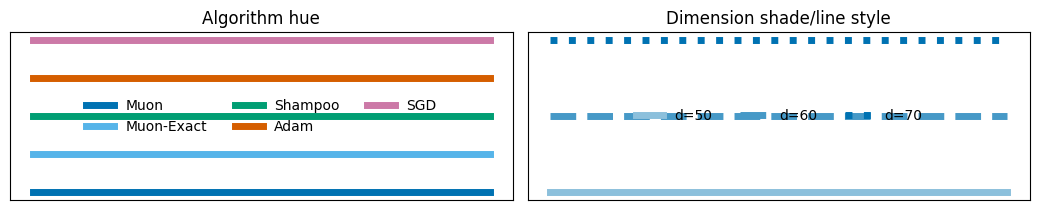

In [8]:
fig, axes = plotting.plot_color_key(run_summary)
show_figure(fig)

### Metric Overview

The Problem cell's question is dimension scaling for direct Matrix Sensing with fixed target law and $m=2dr$; this figure gives the cost-and-accuracy summary of that sweep before the per-step curves.

Read these as three summaries of the same grid. The horizontal coordinate is the ambient matrix dimension $d$, color is the optimizer, and the three panels show executed steps $T$, wall-clock time, and minimum training loss $\min_t \ell_t$. For this notebook, $\ell_t=f(X_t)$ is the Matrix Sensing objective. Each point averages the corresponding run-level statistic over seeds at fixed `(algo, d)`. The second rendering keeps the first two panels unchanged and puts the minimum-loss panel on a log scale, which makes multiplicative accuracy gaps visible.

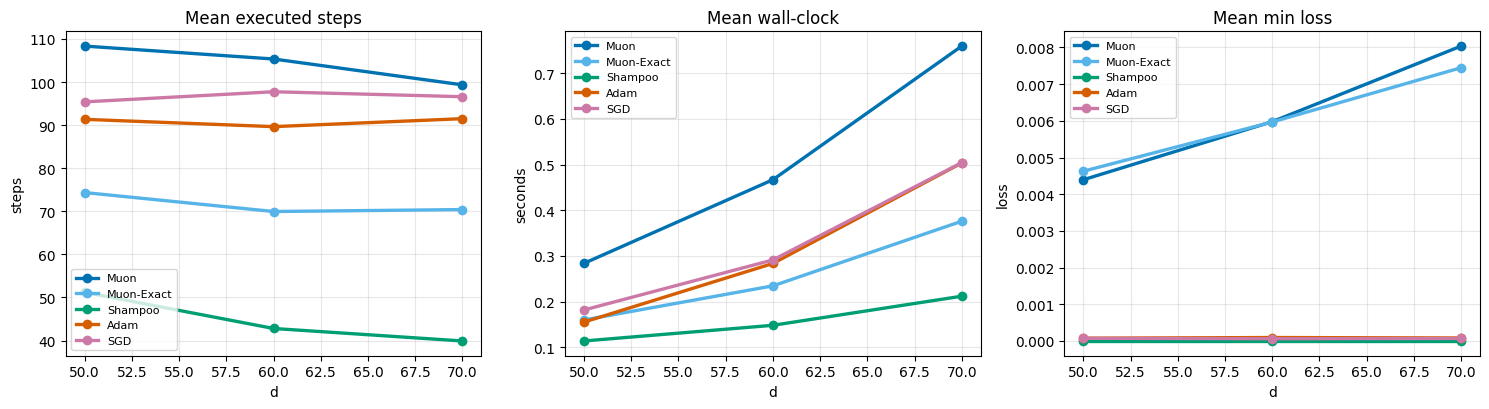

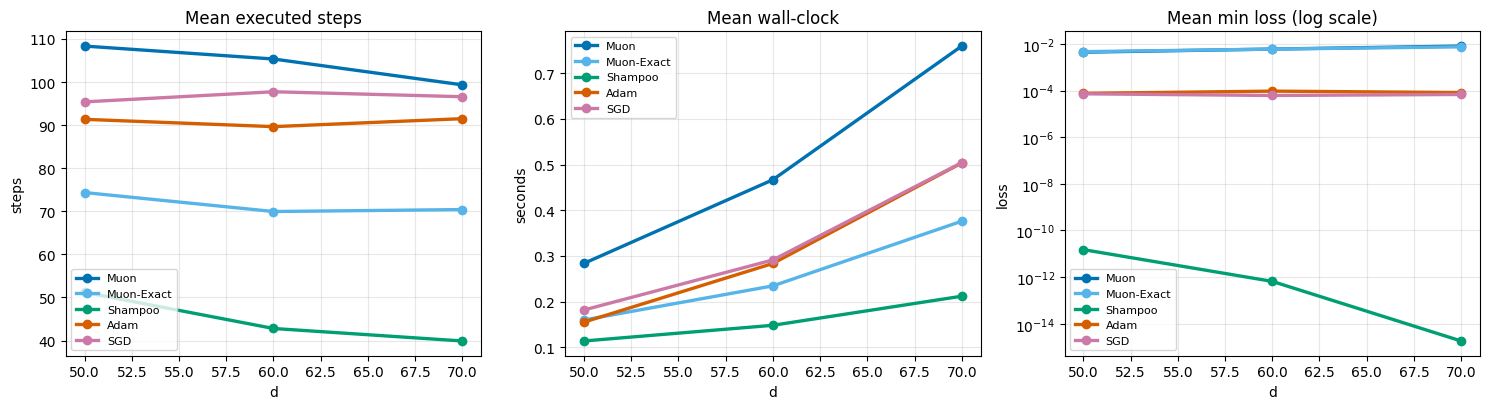

In [9]:
fig, axes = plotting.plot_metric_overview(run_summary, loss_log_y=False)
show_figure(fig)

fig, axes = plotting.plot_metric_overview(run_summary, loss_log_y=True)
show_figure(fig)

### Actual Steps Bar

Because the Problem cell notes that a step becomes more expensive as $d$ grows, this plot isolates the number of optimizer steps from the cost of each step.

This bar chart separates the run budget from the numerical result. The bar group is the optimizer, bar color is dimension $d$, and bar height is the seed average of the last recorded step $T_{\mathrm{run}}$ for that `(algo, d)` group. A shorter bar usually means the early-stopping rule fired; it does not by itself say the method is cheaper per step.

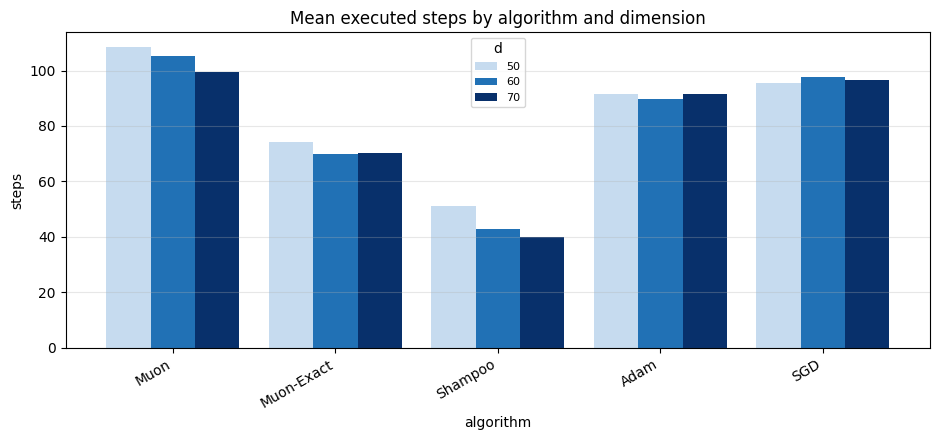

In [10]:
fig, ax = plotting.plot_metric_bar(run_summary, "actual_steps_mean", "Mean executed steps by algorithm and dimension", "steps")
show_figure(fig)

### Wall Clock Bar

This is the runtime counterpart of the Problem cell’s scaling discussion: it includes both the number of steps and the dense sensing cost per step.

This is the realized cost view. The bar group is optimizer, bar color is $d$, and bar height is the seed-averaged final elapsed time. Compare it with the previous step-count plot: if two methods use similar $T_{\mathrm{run}}$ but different wall-clock time, the difference is per-step linear algebra cost rather than convergence length.

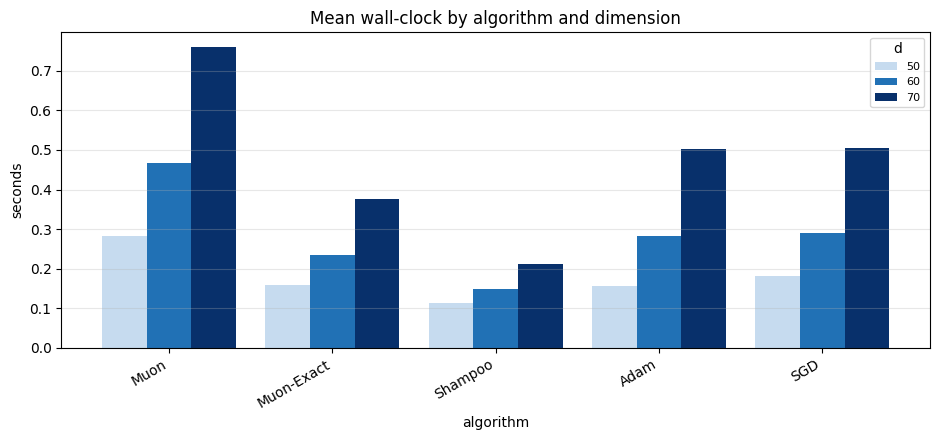

In [11]:
fig, ax = plotting.plot_metric_bar(run_summary, "time_s_mean", "Mean wall-clock by algorithm and dimension", "seconds")
show_figure(fig)

### Minimum Loss Bar

This plot uses the objective $f(X)$ defined in the Problem cell and asks how low each optimizer ever drives that objective for each $d$.

This plot answers how low each method ever got during the run. The bar group is optimizer, bar color is $d$, and the height is $\mathbb{E}_{\mathrm{seed}}[\min_t \ell_t]$ at fixed `(algo, d)`. The linear-scale plot shows absolute differences; the log-scale plot is the one to use when losses span orders of magnitude.

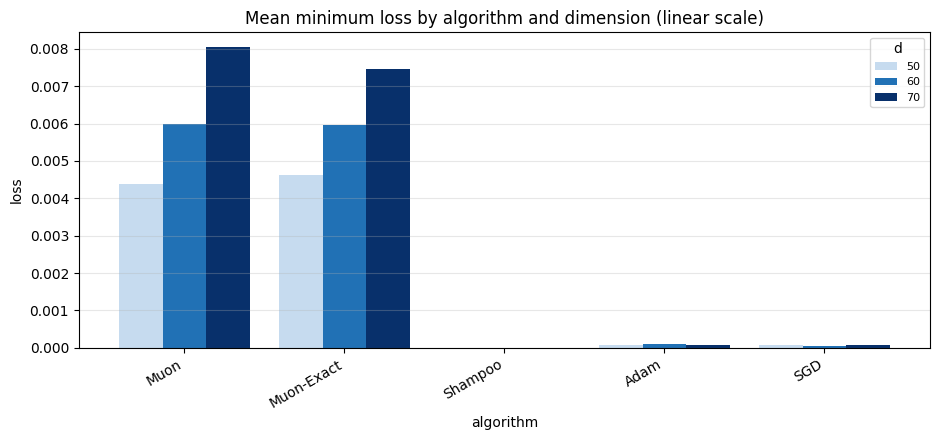

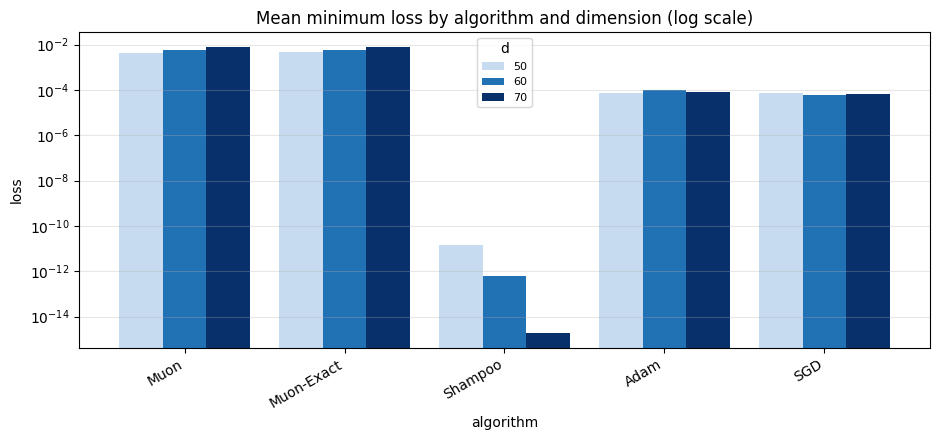

In [12]:
fig, ax = plotting.plot_metric_bar(run_summary, "min_loss_mean", "Mean minimum loss by algorithm and dimension (linear scale)", "loss")
show_figure(fig)

fig, ax = plotting.plot_metric_bar(run_summary, "min_loss_mean", "Mean minimum loss by algorithm and dimension (log scale)", "loss", log_y=True)
show_figure(fig)

### Final Loss Bar

This uses the same Matrix Sensing objective $f(X)$ defined in the Problem cell, but evaluates the final iterate rather than the best iterate reached during training.

This plot uses the endpoint instead of the best point. The bar group is optimizer, bar color is $d$, and the height is $\mathbb{E}_{\mathrm{seed}}[\ell_T]$, where $T$ is the final recorded step for that run. Comparing this with the minimum-loss bar tells whether an optimizer reaches a good value and stays there or only visits it transiently.

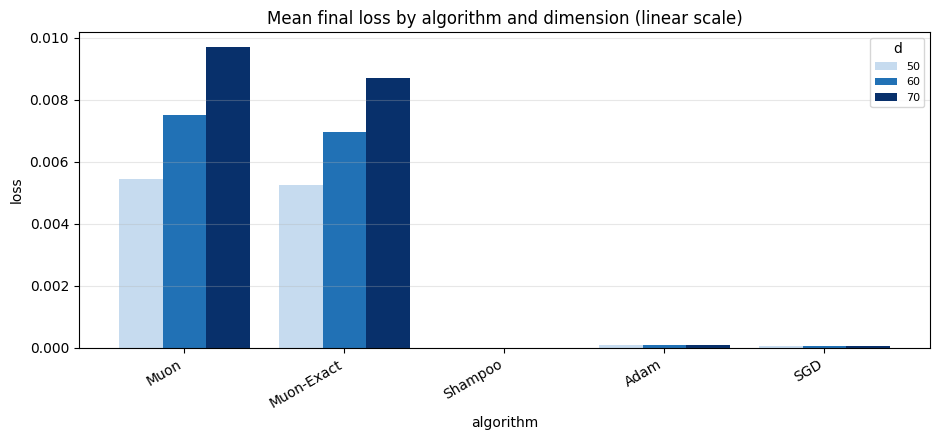

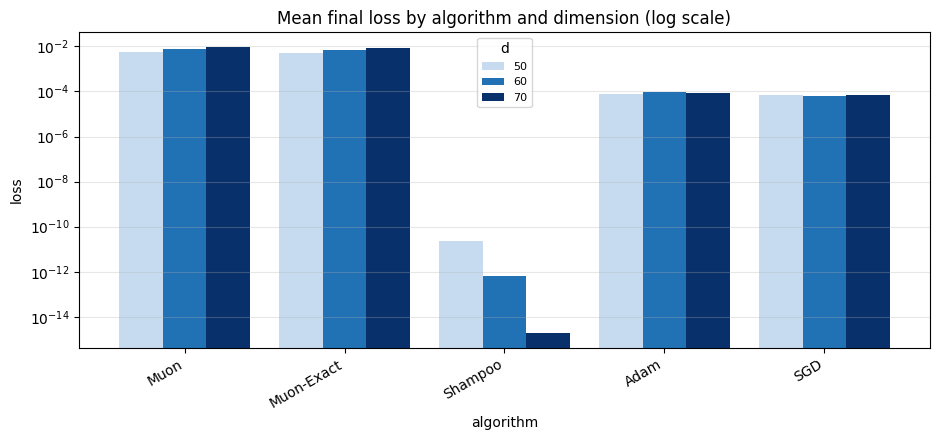

In [13]:
fig, ax = plotting.plot_metric_bar(run_summary, "final_loss_mean", "Mean final loss by algorithm and dimension (linear scale)", "loss")
show_figure(fig)

fig, ax = plotting.plot_metric_bar(run_summary, "final_loss_mean", "Mean final loss by algorithm and dimension (log scale)", "loss", log_y=True)
show_figure(fig)

### Same Dimension Algorithm Comparisons

The Problem cell varies optimizer and $d$; here $d$ is fixed so the plot is a clean optimizer comparison on the same sensing problem size.

Each generated figure fixes one matrix dimension $d$, so all lines in that figure solve problems of the same size. The horizontal axis is optimization step $t$, the vertical axis is the seed-mean loss $\mathbb{E}_{\mathrm{seed}}[\ell_t]$, and color distinguishes optimizers. The linear plot shows early-time absolute motion; the log plot is better for comparing convergence rates and final accuracy at the same $d$.

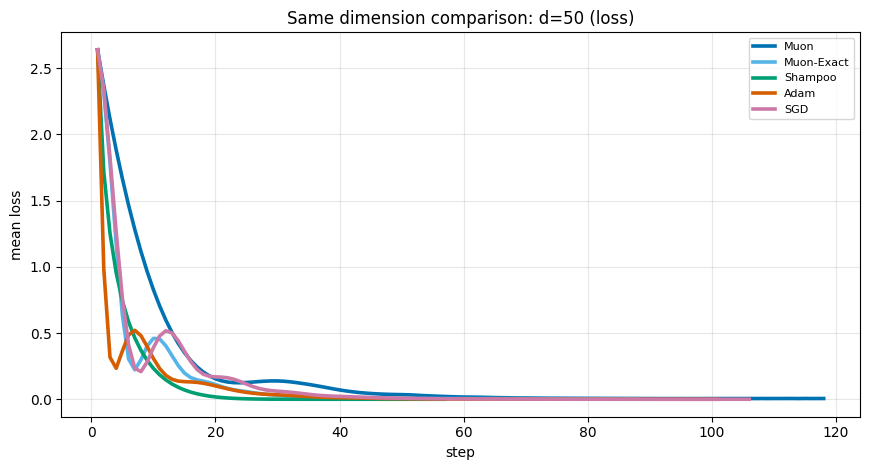

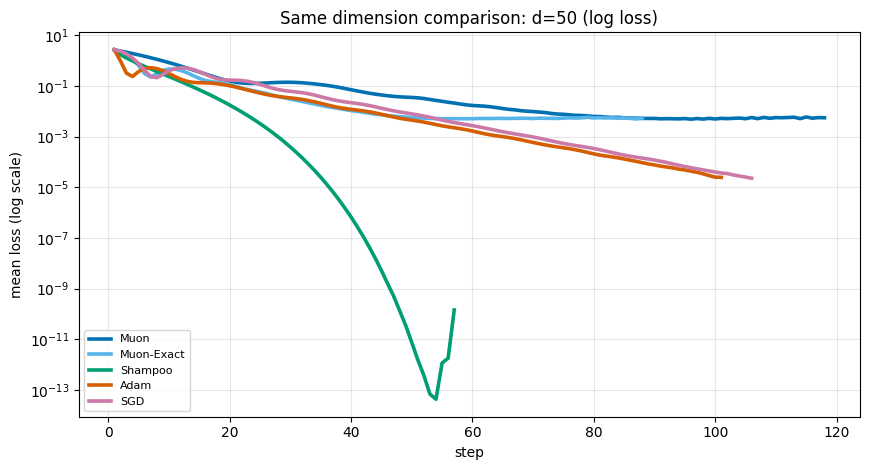

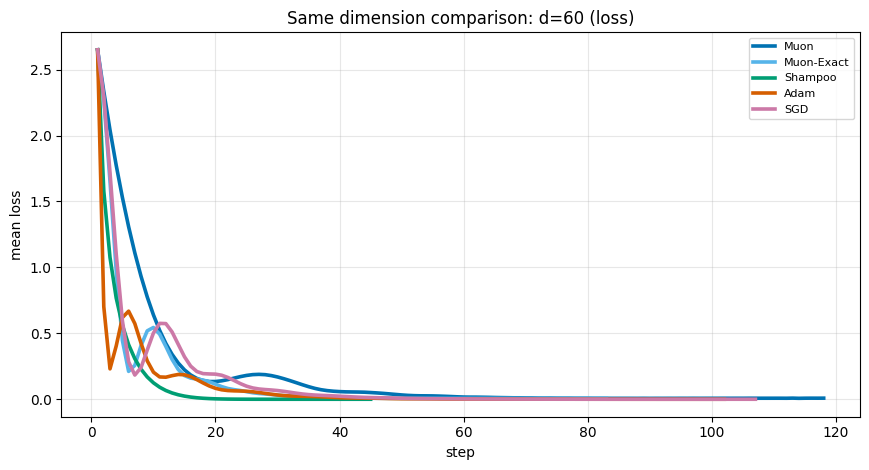

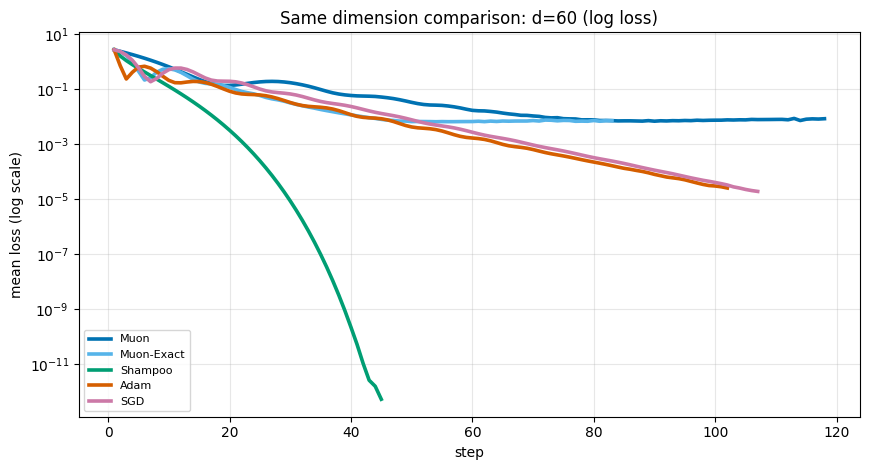

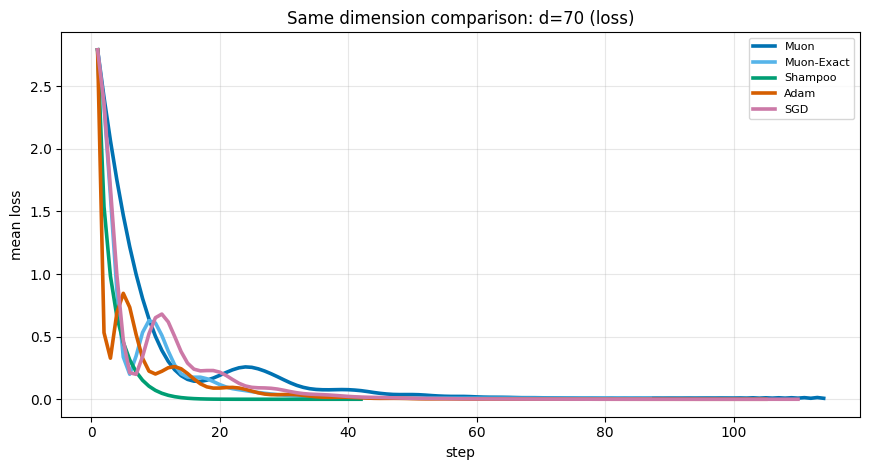

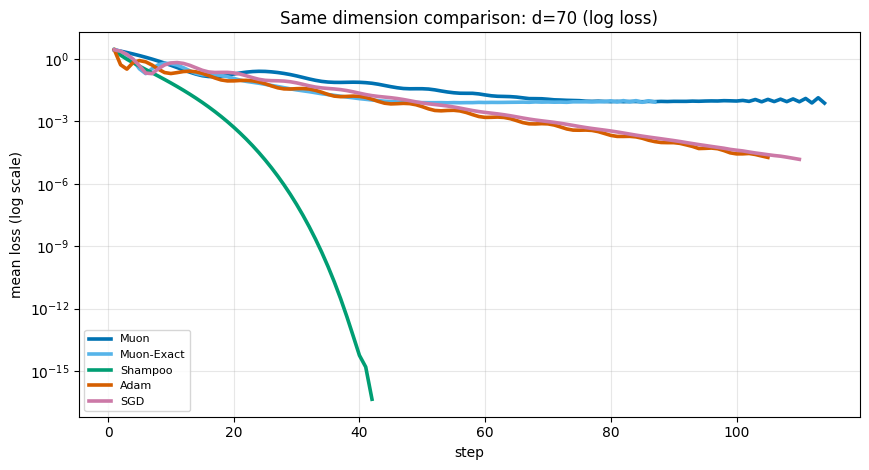

In [14]:
for d in plotting.ordered_dims_in(run_summary):
    for log_y in (False, True):
        fig, ax = plotting.plot_algorithms_for_dimension(trajectories, d, log_y=log_y)
        show_figure(fig)

### Same Algorithm Dimension Comparisons

This is the complementary view of the Problem cell grid: optimizer is fixed, and the dimension variable $d$ is exposed through separate curves.

Here the optimizer is fixed and the lines vary $d$. The horizontal axis is step $t$, the vertical axis is seed-mean loss, and shade/line style encodes dimension. This is the cleanest plot for asking whether one optimizer slows down, becomes unstable, or changes convergence shape as the ambient dimension grows.

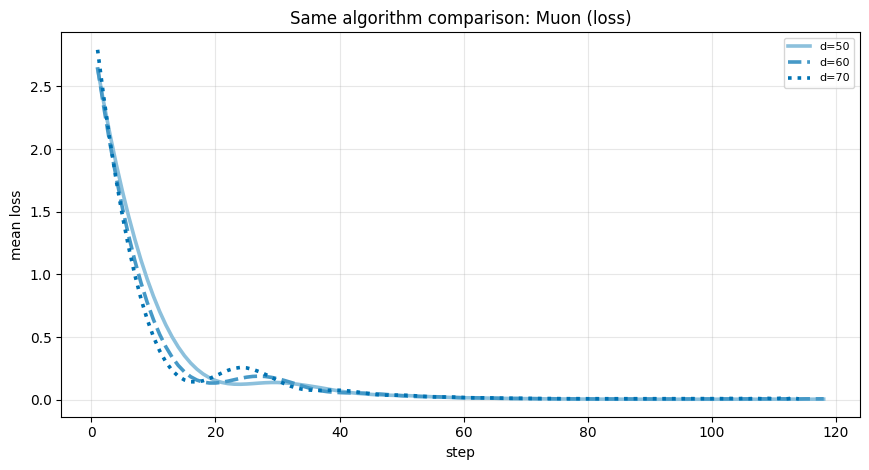

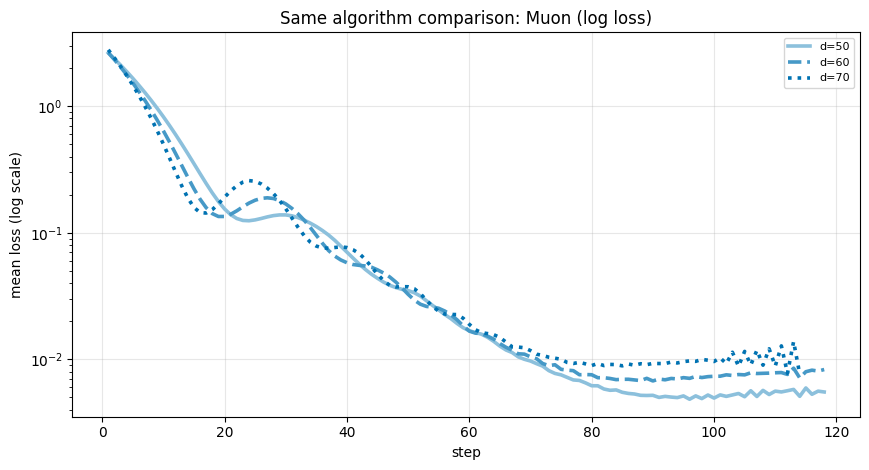

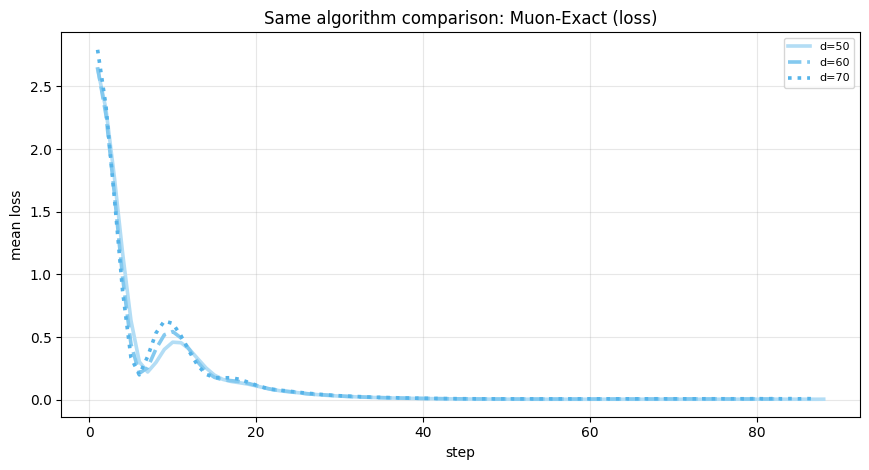

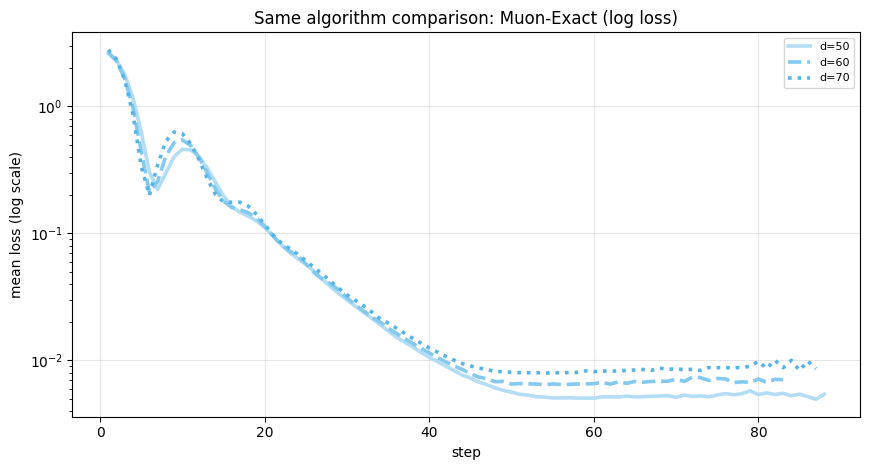

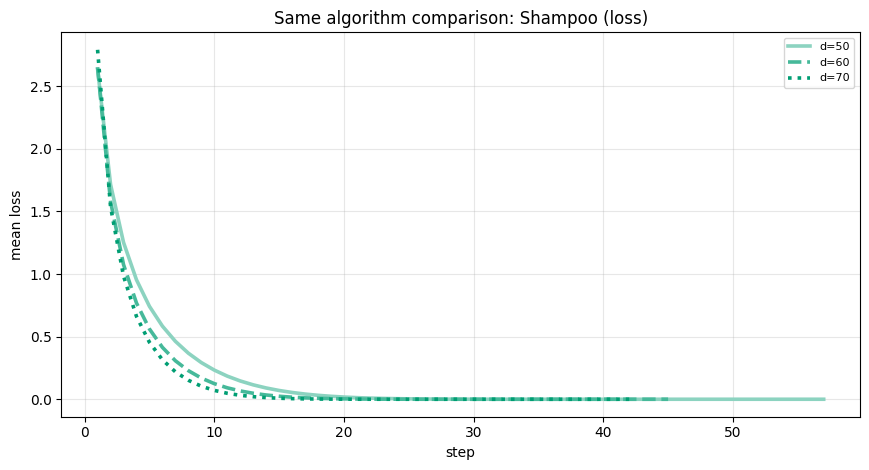

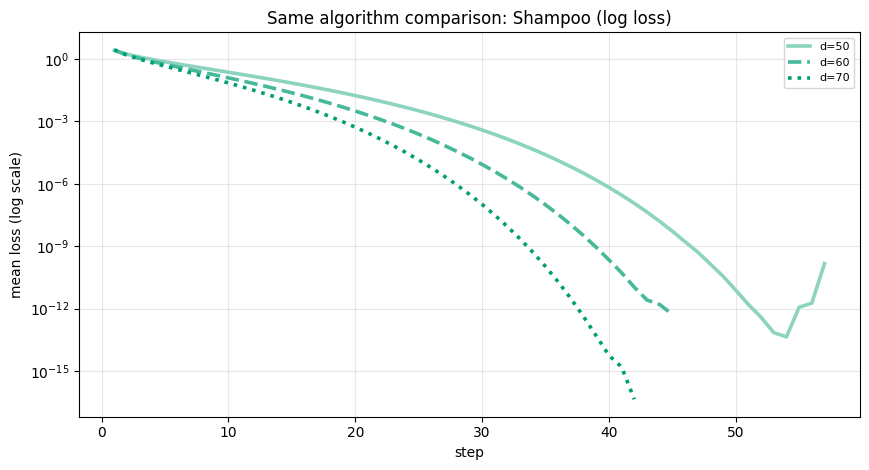

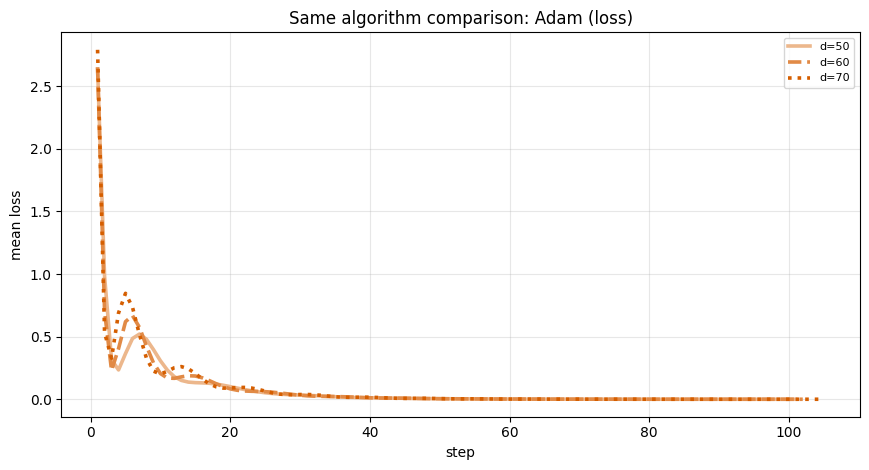

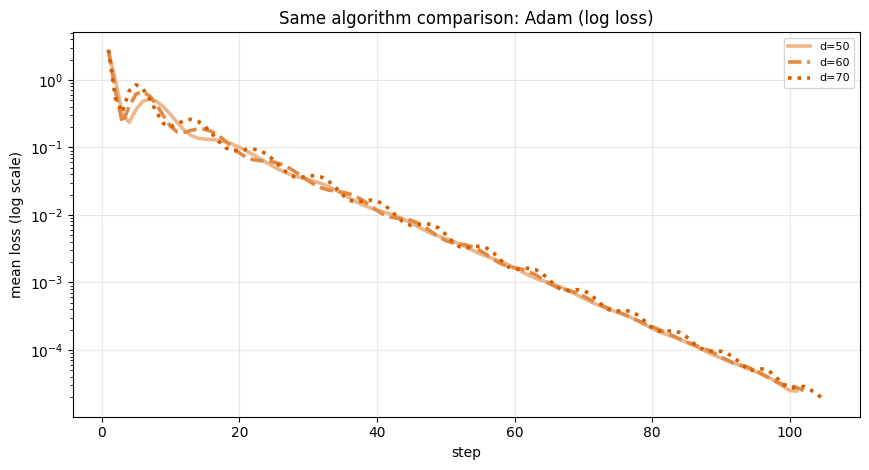

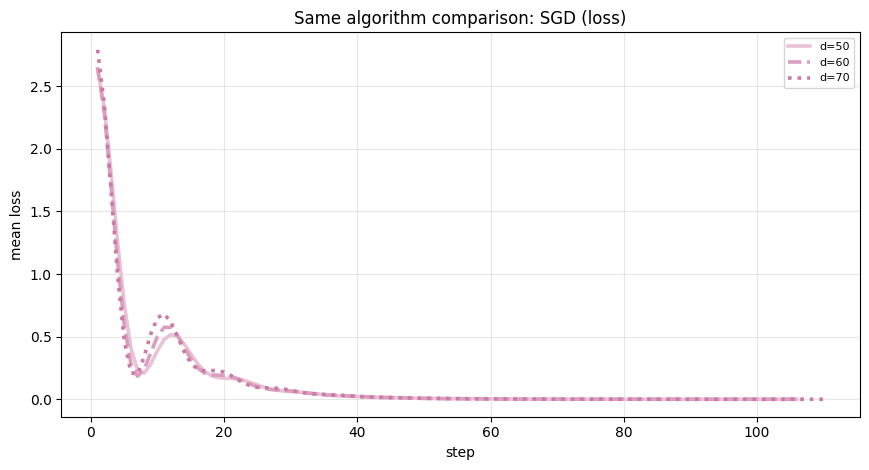

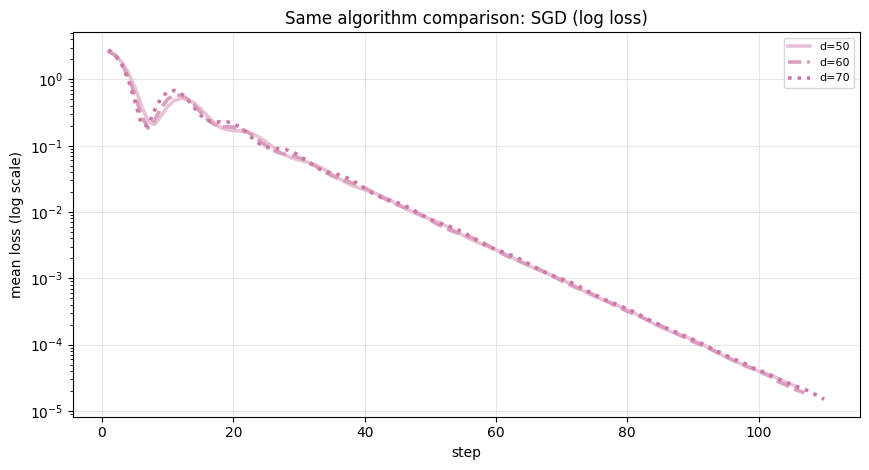

In [15]:
for algo in plotting.ordered_algos_in(run_summary):
    for log_y in (False, True):
        fig, ax = plotting.plot_dimensions_for_algorithm(trajectories, algo, log_y=log_y)
        show_figure(fig)

### All Mean Curves

This combines the full dimension-scaling benchmark from the Problem cell into one view, so every line is one optimizer-dimension slice of that grid.

This deliberately overlays the whole benchmark. One line corresponds to one `(optimizer, d)` pair, with loss first averaged over seeds at each step. The horizontal axis is $t$ and the vertical axis is $\mathbb{E}_{\mathrm{seed}}[\ell_t]$. Use it as a global consistency check; then use the split-by-dimension or split-by-optimizer plots above to inspect a specific comparison without overplotting.

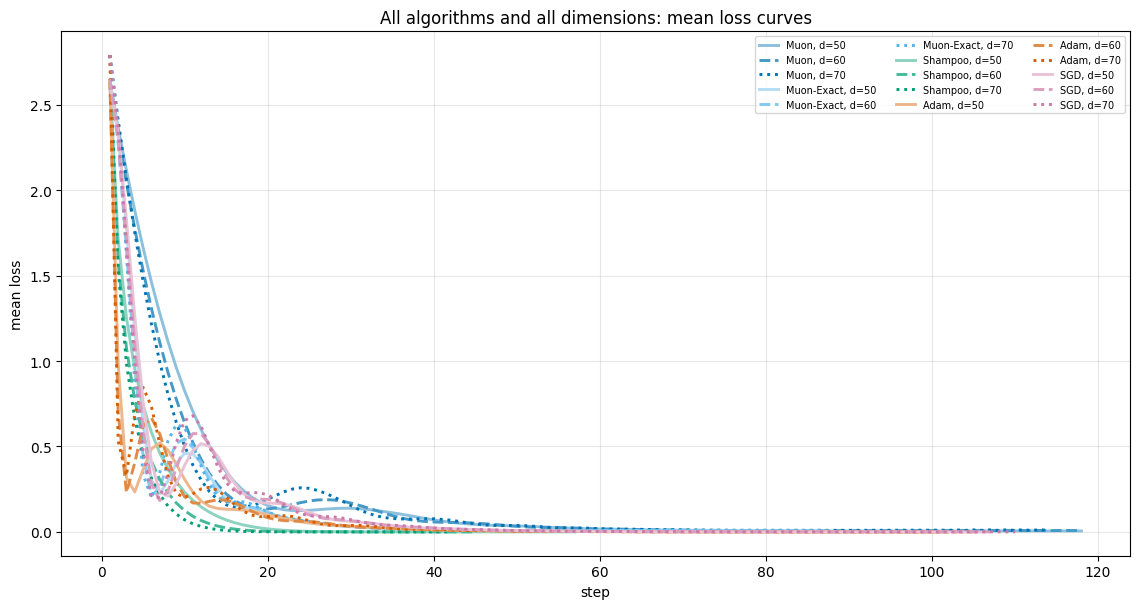

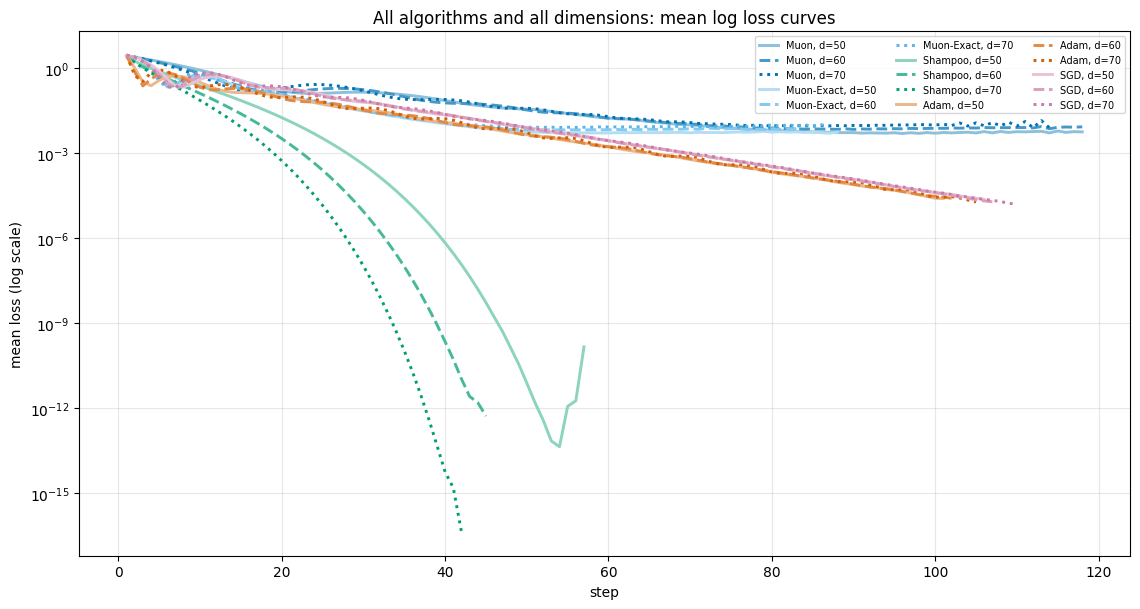

In [16]:
fig, ax = plotting.plot_all_mean_curves_combined(trajectories, log_y=False)
show_figure(fig)

fig, ax = plotting.plot_all_mean_curves_combined(trajectories, log_y=True)
show_figure(fig)

### Algorithm-Dimension Grid

This is the same Problem cell grid laid out spatially: optimizer and dimension become row and column instead of overlapping lines.

This grid removes line overlap by assigning one subplot to each `(optimizer, d)` pair. Rows are optimizers, columns are dimensions, the horizontal axis inside every subplot is step $t$, and the vertical axis is the seed-mean loss. Because the axes are shared, vertical differences across cells are meaningful; this view makes unusually slow or stalled cells easy to spot.

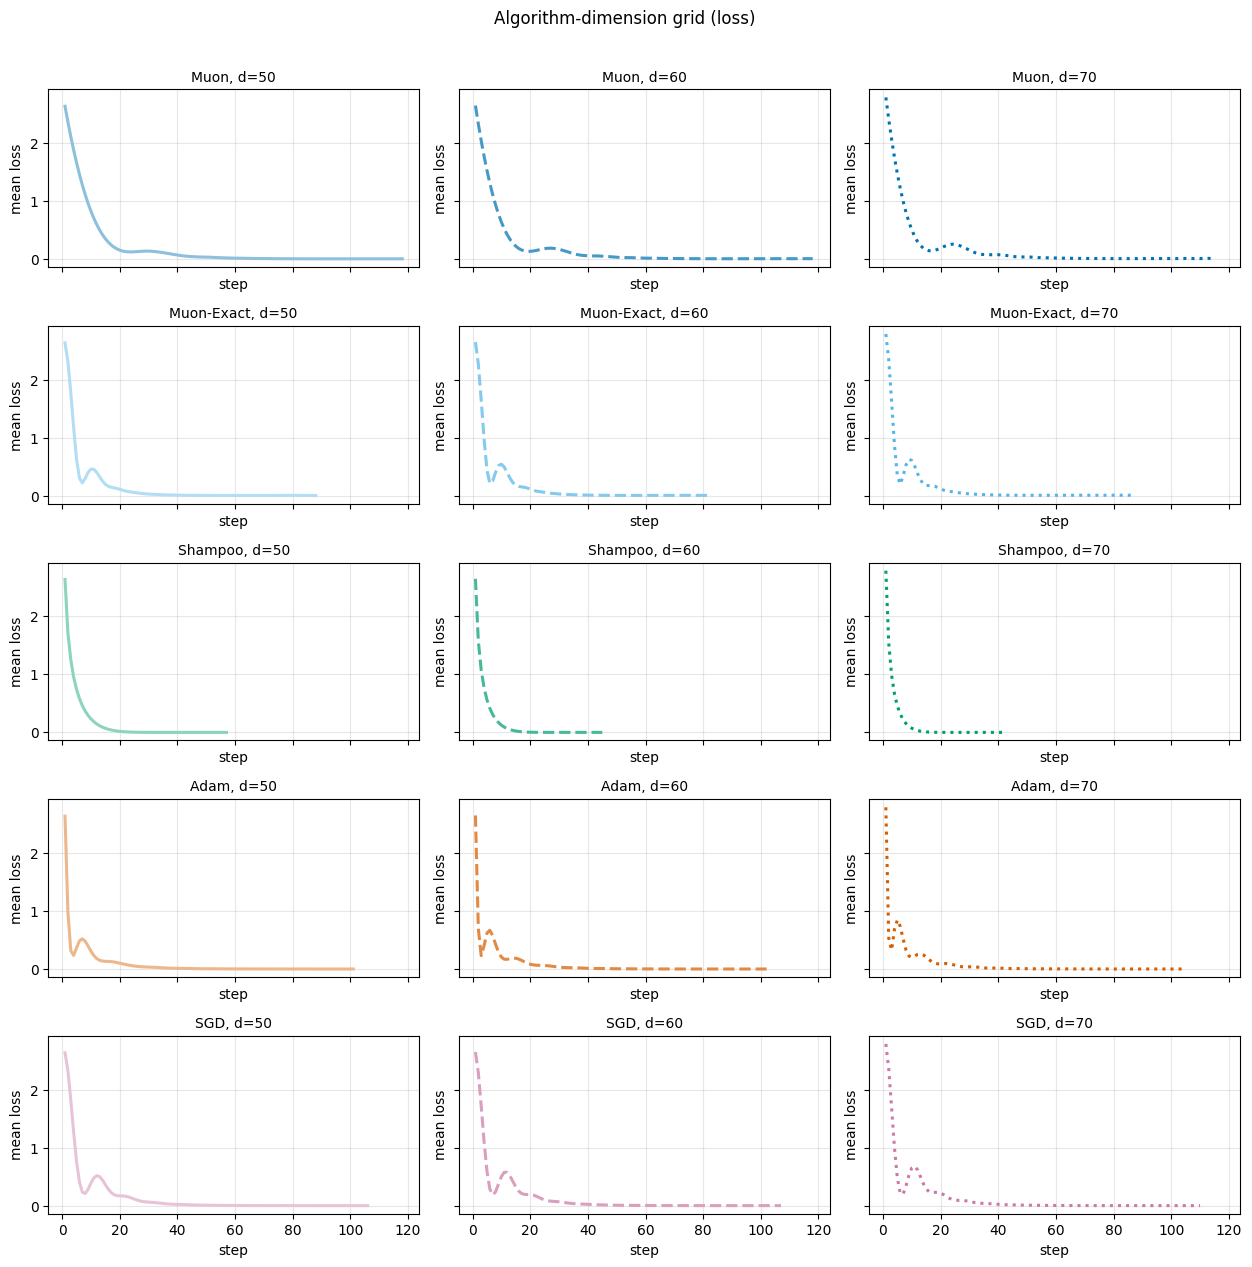

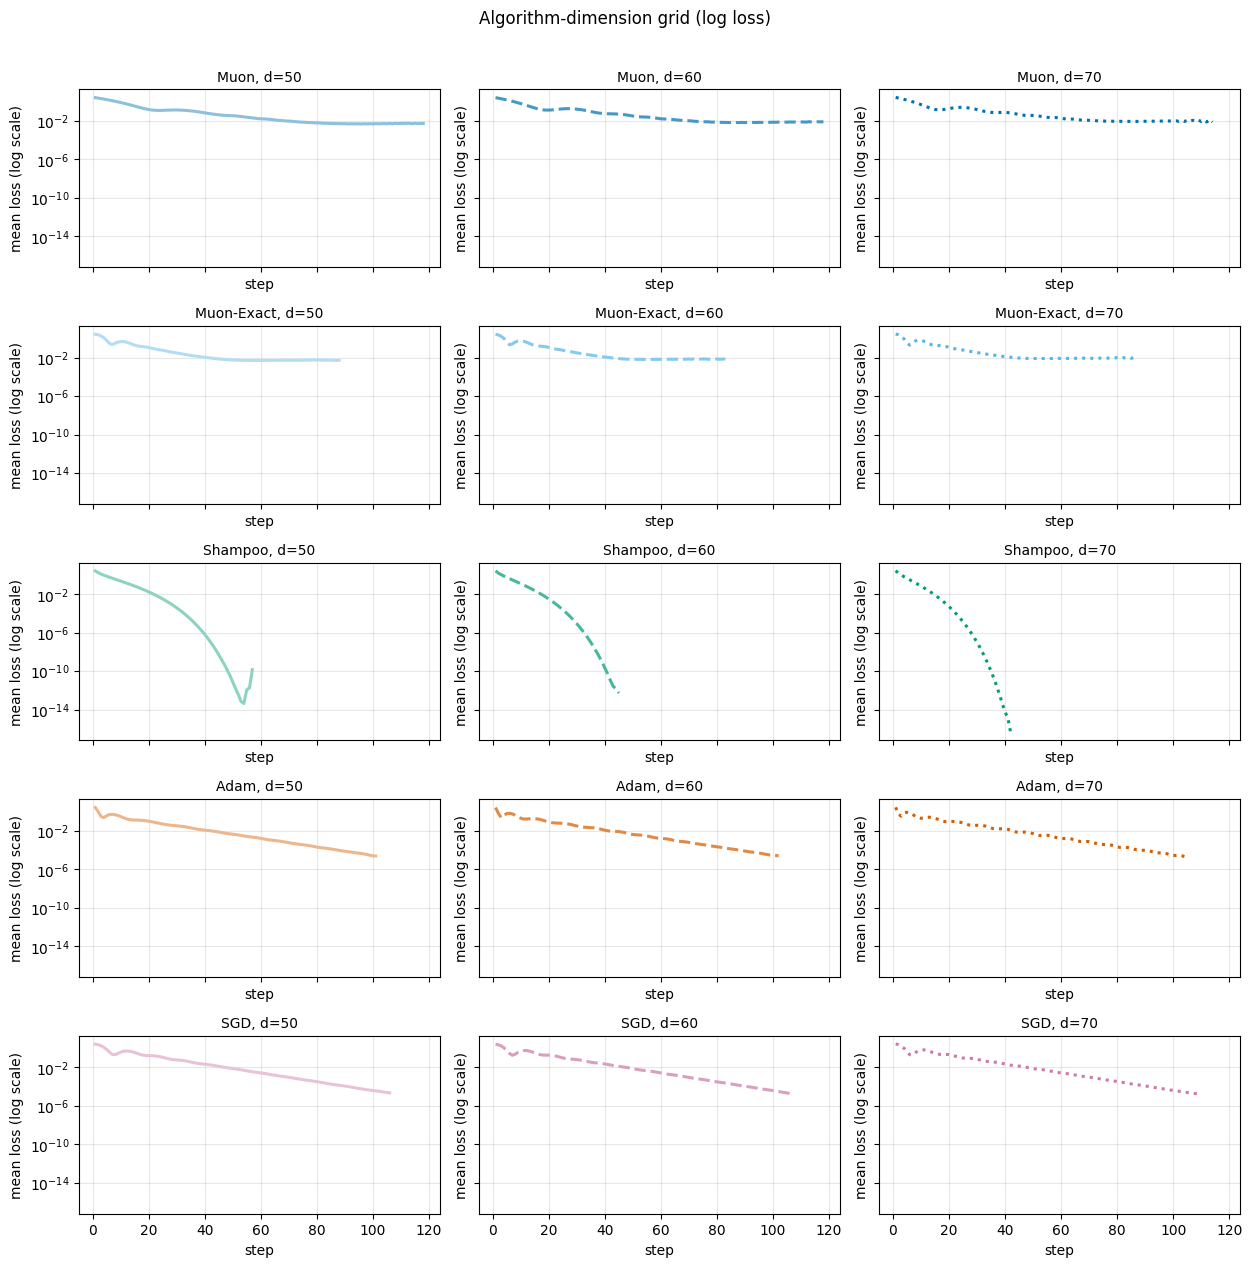

In [17]:
fig, axes = plotting.plot_algorithm_dimension_grid(trajectories, log_y=False)
show_figure(fig)

fig, axes = plotting.plot_algorithm_dimension_grid(trajectories, log_y=True)
show_figure(fig)

### Seed Variability By Dimension

The Problem cell includes repeated random targets, measurements, and initializations; this plot opens that seed dimension instead of averaging it away.

Each figure fixes $d$ and shows individual runs rather than seed averages. The horizontal axis is step $t$, the vertical axis is the raw loss $\ell_t$ for one seed, color is optimizer, and each faint curve is one `(algo, d, seed)` trajectory. Use this to see whether a mean curve is representative or is hiding outlier seeds.

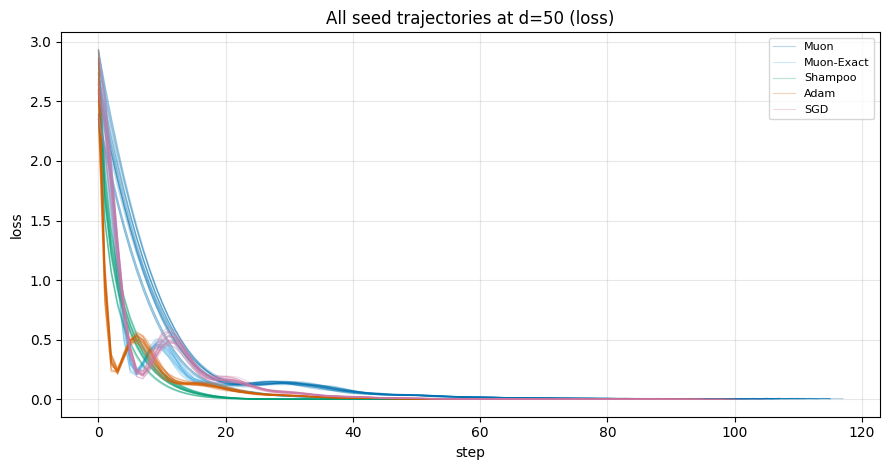

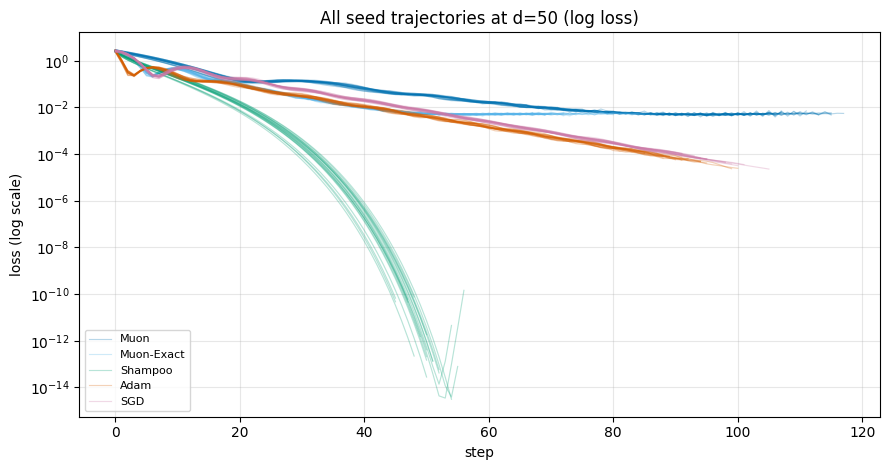

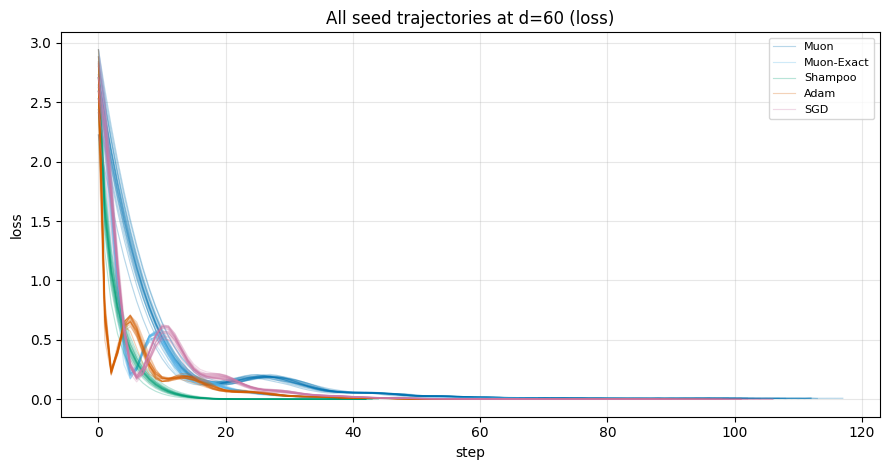

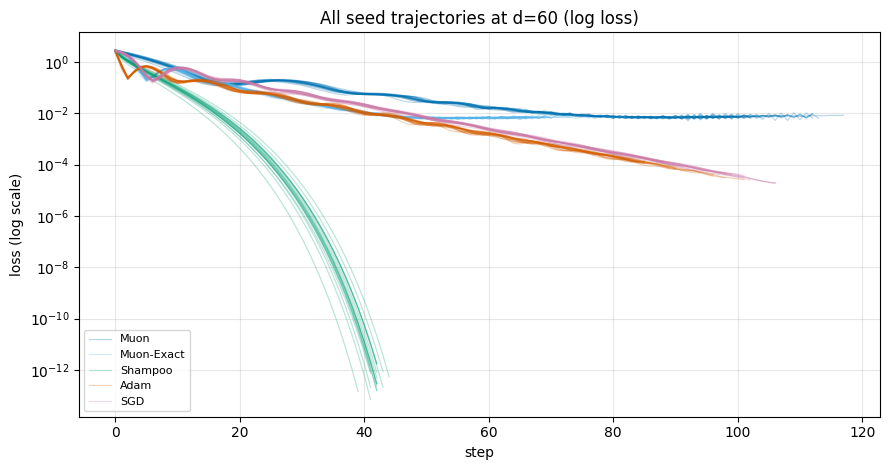

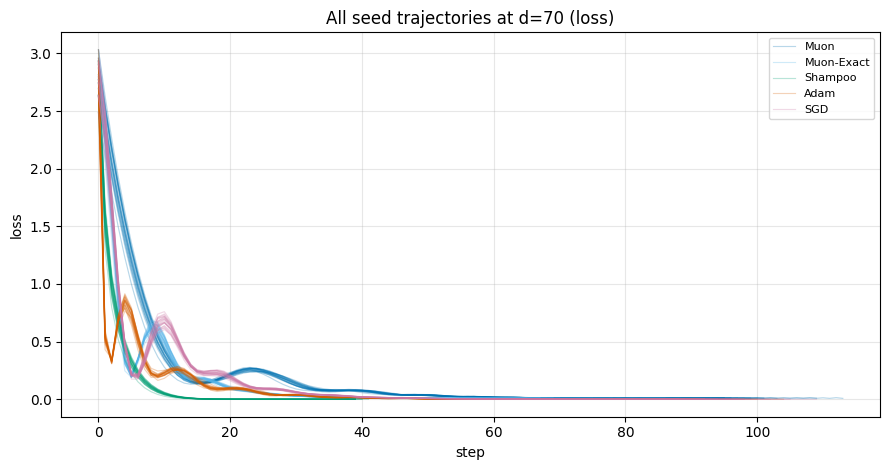

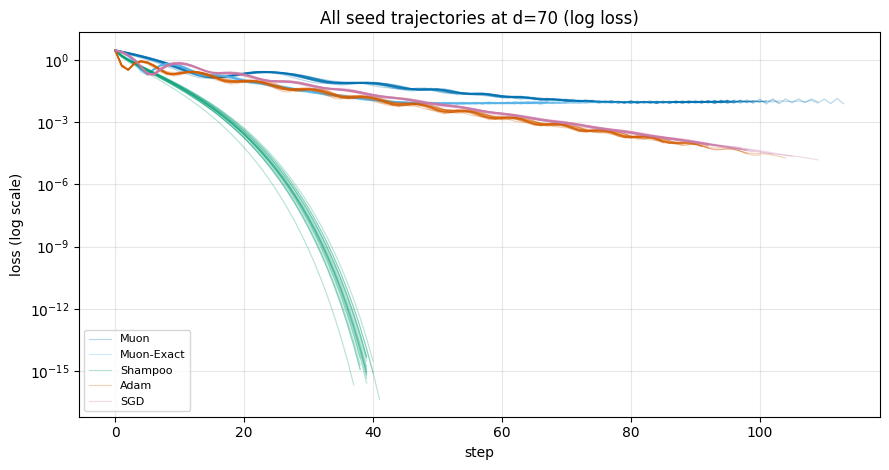

In [18]:
for d in plotting.ordered_dims_in(run_summary):
    for log_y in (False, True):
        fig, ax = plotting.plot_seed_variability_for_dimension(trajectories, d, log_y=log_y)
        show_figure(fig)

### Conclusion

In [19]:
def conclusion_markdown(run_summary):
    summary = plotting.summary_table(run_summary)
    max_steps = int(run_summary["iters"].sum())
    actual_steps = int(run_summary["actual_steps"].sum())
    stopped = int(run_summary["stopped_early"].sum())
    lines = [
        "### Result Summary",
        "",
        f"- Runs: `{len(run_summary)}`",
        f"- Methods: `{', '.join(sorted(run_summary['algo'].unique()))}`",
        f"- Max iterations per run: `{int(run_summary['iters'].iloc[0])}`",
        f"- Max optimizer-step budget: `{max_steps}`",
        f"- Executed optimizer steps: `{actual_steps}` (`{max_steps - actual_steps}` skipped by early stopping)",
        f"- Early-stopped runs: `{stopped}/{len(run_summary)}`",
        "",
    ]
    for d in sorted(run_summary["d"].unique()):
        sub = summary[summary["d"] == d]
        fewest_steps = sub.loc[sub["actual_steps_mean"].idxmin()]
        best_time = sub.loc[sub["time_s_mean"].idxmin()]
        best_loss = sub.loc[sub["min_loss_mean"].idxmin()]
        lines.append(
            f"- d={d}: fewest executed steps is `{fewest_steps.algo}` at `{fewest_steps.actual_steps_mean:.1f}` steps; "
            f"fastest wall-clock is `{best_time.algo}` at `{best_time.time_s_mean:.3f}s`; "
            f"lowest min_loss is `{best_loss.algo}` at `{best_loss.min_loss_mean:.3e}`."
        )
    lines.append("")
    lines.append("Muon vs Muon-Exact checks whether the Newton-Schulz approximation tracks the exact SVD polar direction.")
    lines.append("Compare actual steps, wall-clock, and minimum loss together when judging optimizer efficiency.")
    return "\n".join(lines)


IPython.display.display(IPython.display.Markdown(conclusion_markdown(run_summary)))

### Result Summary

- Runs: `300`
- Methods: `Adam, Muon, Muon-Exact, SGD, Shampoo`
- Max iterations per run: `2000`
- Max optimizer-step budget: `600000`
- Executed optimizer steps: `24478` (`575522` skipped by early stopping)
- Early-stopped runs: `300/300`

- d=50: fewest executed steps is `Shampoo` at `51.2` steps; fastest wall-clock is `Shampoo` at `0.114s`; lowest min_loss is `Shampoo` at `1.504e-11`.
- d=60: fewest executed steps is `Shampoo` at `42.8` steps; fastest wall-clock is `Shampoo` at `0.148s`; lowest min_loss is `Shampoo` at `6.541e-13`.
- d=70: fewest executed steps is `Shampoo` at `39.9` steps; fastest wall-clock is `Shampoo` at `0.212s`; lowest min_loss is `Shampoo` at `1.823e-15`.

Muon vs Muon-Exact checks whether the Newton-Schulz approximation tracks the exact SVD polar direction.
Compare actual steps, wall-clock, and minimum loss together when judging optimizer efficiency.

### Hypothesis Verdict Table

| hypothesis | evidence | supported? | caveat |
|---|---|---|---|
| Direct Matrix Sensing should expose optimizer loss/runtime tradeoffs as dimension changes. | Dimension grids, mean loss curves, actual-step bars, and runtime panels compare methods at each d. | Yes | This is a training-loss benchmark; recovery and theory-specific layer diagnostics are not the main target. |
| Muon-family behavior should be judged against both exact polar updates and standard baselines. | The notebook includes Muon, Muon-Exact, Shampoo, Adam, and SGD with shared seeds and stopping rules. | Partial | The verdict depends on loss, steps, and wall-clock jointly; no single method is uniformly best on every axis. |
